In [1]:
import pyteomics
import lxml
from pyteomics import mzml, mass
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib import pyplot
import matplotlib
import seaborn as sns
import re
import statistics

# proteome quantification starts here

In [2]:
df_pro=pd.read_csv(r'D:\\yuming\\2023\\20230312\\quantification\\csodiaq\\common_peptides.csv')
dfdf_pro=pd.read_csv(r'D:\\yuming\\2023\\20230312\\quantification\\csodiaq2\\common_proteins.csv')


In [3]:
df_pro.set_index('Unnamed: 0',inplace=True)
dfdf_pro.set_index('Unnamed: 0',inplace=True)

In [4]:
df_pro=df_pro.drop(columns=['mean','std'])
dfdf_pro=dfdf_pro.drop(columns=['mean','std'])

In [5]:
dfdf_pro

,:/yuming/2023/20230312/quantification/mzxml/MIX_1_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_2_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_2_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_2_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_3.mzXML
Unnamed: 0,,,,,,,,,,,,,,,,,,
1/sp|P38646|GRP75_HUMAN,1.883007e+06,1.825089e+06,1.643882e+06,1.325070e+06,1.395113e+06,1.335178e+06,9.361405e+05,9.488419e+05,8.927131e+05,508684.598755,530802.561798,503666.665344,248123.107147,266223.670013,218234.938904,174050.645538,165661.527740,166600.903412
1/sp|O43175|SERA_HUMAN,3.095314e+06,2.938652e+06,2.848389e+06,2.315225e+06,2.276209e+06,2.394076e+06,1.505971e+06,1.361888e+06,1.526284e+06,882100.724609,912653.998322,883920.933624,448501.453796,465816.754059,465365.613007,268691.418549,257780.386261,266154.776459
2/sp|P30613|KPYR_HUMAN/sp|P14618|KPYM_HUMAN,6.503682e+05,6.009059e+05,6.323908e+05,5.945457e+05,5.564888e+05,2.642191e+05,4.065307e+05,3.855737e+05,3.629054e+05,215720.923462,225464.015930,218863.725281,116721.044189,114355.254578,107176.983276,60290.933044,55204.839630,53811.680023
1/sp|P62258|1433E_HUMAN,2.345816e+06,2.035966e+06,2.136693e+06,1.812164e+06,1.858982e+06,1.859142e+06,1.197425e+06,1.164987e+06,1.140138e+06,707867.302032,696227.177063,752322.603241,422198.616089,393954.962463,386427.260620,248354.222748,224938.131714,229200.172089
2/sp|P52597|HNRPF_HUMAN/sp|P31943|HNRH1_HUMAN,1.174246e+05,1.079344e+05,1.007789e+05,9.673529e+04,1.105527e+05,8.756707e+04,9.275247e+04,8.700066e+04,9.883621e+04,81516.492615,63345.552002,79662.860199,46055.222229,44942.956268,23682.048065,26976.878235,28210.052155,28713.259613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4/sp|Q6ZMR3|LDH6A_HUMAN/sp|P07195|LDHB_HUMAN/sp|P07864|LDHC_HUMAN/sp|P00338|LDHA_HUMAN,6.341850e+05,5.619379e+05,5.660673e+05,4.891812e+05,4.805854e+05,4.780410e+05,3.438484e+05,3.631056e+05,3.625125e+05,223703.493286,202718.514038,208798.354370,115295.428772,112859.358948,125358.149261,71992.886902,70631.236053,69271.115204
1/sp|P62244|RS15A_HUMAN,1.694706e+06,1.281050e+06,1.302620e+06,1.068906e+06,1.059451e+06,1.082343e+06,7.204070e+05,5.210621e+05,6.773839e+05,326690.551270,333765.373138,330348.798584,216521.088135,216564.130310,187433.898224,129514.115753,132032.214539,130216.622955
2/sp|Q92841|DDX17_HUMAN/sp|P17844|DDX5_HUMAN,9.426514e+05,9.969261e+05,1.010627e+06,9.043936e+05,8.484640e+05,9.008724e+05,6.599193e+05,3.637962e+05,5.969961e+05,398717.403656,377394.227020,377106.197784,197089.095886,186693.441101,200102.411438,112817.641602,108496.125397,113169.543365


In [6]:
# calculate cv of targeted m/z 

cv = lambda x: np.std(x, ddof=1) / np.mean(x) * 100 

In [7]:
df=df_pro

PRO1=df.iloc[:,:3].T
PRO2=df.iloc[:,3:6].T
PRO3=df.iloc[:,6:9].T
PRO4=df.iloc[:,9:12].T
PRO5=df.iloc[:,12:15].T


In [8]:
newdf={'PRO1':PRO1.apply(cv).tolist(),
    'PRO2':PRO2.apply(cv).tolist(),
    'PRO3':PRO3.apply(cv).tolist(),
    'PRO4':PRO4.apply(cv).tolist(),
    'PRO5':PRO5.apply(cv).tolist()}

In [9]:
uk=pd.DataFrame.from_dict(newdf, orient='index')
um=uk.transpose()

In [10]:
#haha = um[um['PRO1'] <= 100]

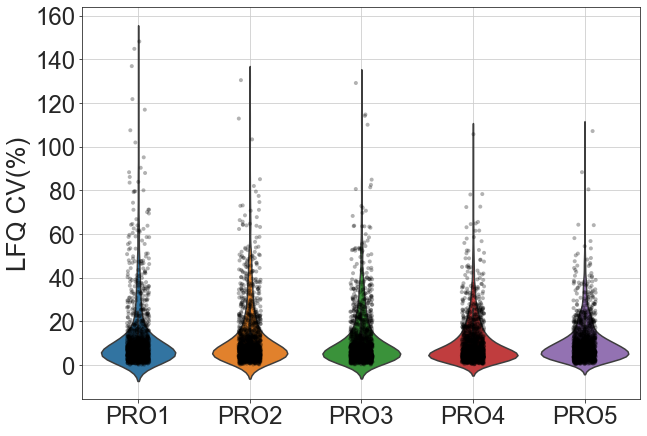

In [11]:
matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(10, 7.2))
sns.set_style("ticks")


sns.violinplot(data=um)
sns.stripplot(data=um, jitter=True,alpha=0.3,size=4, color="black")
plt.ylabel('LFQ CV(%)', fontsize=26)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.grid()

In [5]:
df_pro10=np.log10(df_pro)
df_pro10

,:/yuming/2023/20230312/quantification/mzxml/MIX_1_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_3.mzXML
Unnamed: 0,,,,,,,,,,,,,,,
LAAVDATVNQVLASR,5.622096,5.657082,5.628375,5.339483,5.357352,5.301720,5.127944,5.091451,5.079555,4.789577,4.773545,4.805487,4.488853,4.529699,4.491807
LVVEC(UniMod:4)VMNNVTC(UniMod:4)TR,5.263455,5.281970,5.240899,5.069423,5.032393,5.070524,4.872495,4.780918,4.839713,4.502446,4.479683,4.514014,4.267950,4.205645,4.248025
SQIHDIVLVGGSTR,4.897433,4.378275,4.436572,5.476830,5.046673,5.037189,5.213443,4.930679,4.947367,4.783842,4.935684,4.917023,4.698745,4.682609,4.670985
LATQLTGPVMPVR,5.954935,5.958405,5.322815,5.303346,5.302652,5.320801,5.310436,5.196980,5.400264,4.894301,4.865178,4.945624,4.605131,4.731601,4.736138
IDTIEIITDR,5.897174,5.840703,5.863671,5.577980,5.565417,5.617887,5.319273,5.327287,5.325838,5.080797,5.076810,5.087089,4.837365,4.795429,4.822374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
(UniMod:5)SLPLNPKPFLNGLTGKPVMVK,5.181784,5.195313,5.198263,4.942516,5.072903,4.892999,4.839279,4.735841,4.757849,4.443079,4.525908,4.534454,4.359186,4.301445,4.239877
AFVDFLSDEIKEER,5.288411,5.303232,5.306113,5.185040,5.226282,5.177232,4.921185,4.942649,4.869996,4.608917,4.625880,4.630092,4.362558,4.381617,4.372295
MFVGGLSWDTSK,5.216575,5.155522,5.206140,5.105499,5.015137,4.935106,4.832137,4.803120,4.765375,4.621380,4.629345,4.532320,4.368296,4.268101,4.217720


In [12]:
df_pro2=np.log2(df_pro)
df_pro2

,:/yuming/2023/20230312/quantification/mzxml/MIX_1_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_3.mzXML
Unnamed: 0,,,,,,,,,,,,,,,
LAAVDATVNQVLASR,18.676200,18.792421,18.697055,17.737379,17.796738,17.611932,17.034660,16.913435,16.873915,15.910630,15.857375,15.963481,14.911647,15.047334,14.921461
LVVEC(UniMod:4)VMNNVTC(UniMod:4)TR,17.484818,17.546324,17.409889,16.840259,16.717246,16.843916,16.186079,15.881865,16.077177,14.956801,14.881183,14.995230,14.177824,13.970852,14.111634
SQIHDIVLVGGSTR,16.268920,14.544314,14.737974,18.193635,16.764686,16.733180,17.318683,16.379362,16.434799,15.891580,16.395989,16.333996,15.608891,15.555289,15.516675
LATQLTGPVMPVR,19.781864,19.793393,17.682009,17.617334,17.615027,17.675318,17.640887,17.263994,17.939289,16.258516,16.161771,16.429008,15.297915,15.718037,15.733110
IDTIEIITDR,19.589989,19.402395,19.478694,18.529647,18.487915,18.662216,17.670242,17.696866,17.692052,16.878042,16.864799,16.898943,16.069377,15.930070,16.019581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
(UniMod:5)SLPLNPKPFLNGLTGKPVMVK,17.213514,17.258456,17.268257,16.418681,16.851818,16.254191,16.075738,15.732125,15.805233,14.759590,15.034739,15.063129,14.480901,14.289089,14.084567
AFVDFLSDEIKEER,17.567720,17.616955,17.626527,17.224332,17.361332,17.198391,16.347822,16.419124,16.177778,15.310490,15.366841,15.380833,14.492104,14.555418,14.524450
MFVGGLSWDTSK,17.329086,17.126274,17.294424,16.960100,16.659924,16.394067,16.052012,15.955620,15.830232,15.351891,15.378352,15.056042,14.511166,14.178326,14.010964


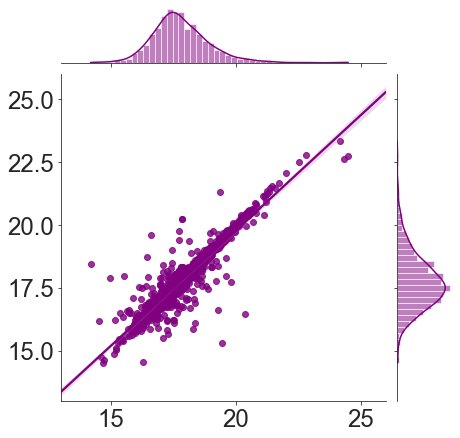

In [44]:
#sns.set_theme(style="darkgrid")
#sns.set(font_scale=1.5)
plt.rcParams['font.family'] = 'Arial'
g=sns.jointplot(x=df_pro2.iloc[:,0].tolist(), 
                  y=df_pro2.iloc[:,1].tolist(),
                  xlim = (13,26), ylim = (13,26),
                  kind="reg", truncate=False,
                  color="purple", height=6)
g.ax_joint.tick_params(labelsize=24)
plt.savefig(r'D:\\project7_SMAD\\figure2\\quantification\\jointplot_pro.svg',dpi=800,bbox_inches='tight')

In [14]:
from scipy.stats import spearmanr

# Two example lists
list1 = df_pro2.iloc[:,0].tolist()
list2 = df_pro2.iloc[:,1].tolist()

# Calculate Spearman's rho and p-value
rho, pval = spearmanr(list1, list2)

# Print the results
print("Spearman's rho =", rho)
print("p-value =", pval)

Spearman's rho = 0.9252540332297795
p-value = 0.0


In [17]:
dfdf=dfdf_pro.drop(dfdf_pro.columns[[3, 4, 5]], axis=1)

In [18]:
dfdf

,:/yuming/2023/20230312/quantification/mzxml/MIX_1_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_3.mzXML
Unnamed: 0,,,,,,,,,,,,,,,
1/sp|P38646|GRP75_HUMAN,1.883007e+06,1.825089e+06,1.643882e+06,9.361405e+05,9.488419e+05,8.927131e+05,508684.598755,530802.561798,503666.665344,248123.107147,266223.670013,218234.938904,174050.645538,165661.527740,166600.903412
1/sp|O43175|SERA_HUMAN,3.095314e+06,2.938652e+06,2.848389e+06,1.505971e+06,1.361888e+06,1.526284e+06,882100.724609,912653.998322,883920.933624,448501.453796,465816.754059,465365.613007,268691.418549,257780.386261,266154.776459
2/sp|P30613|KPYR_HUMAN/sp|P14618|KPYM_HUMAN,6.503682e+05,6.009059e+05,6.323908e+05,4.065307e+05,3.855737e+05,3.629054e+05,215720.923462,225464.015930,218863.725281,116721.044189,114355.254578,107176.983276,60290.933044,55204.839630,53811.680023
1/sp|P62258|1433E_HUMAN,2.345816e+06,2.035966e+06,2.136693e+06,1.197425e+06,1.164987e+06,1.140138e+06,707867.302032,696227.177063,752322.603241,422198.616089,393954.962463,386427.260620,248354.222748,224938.131714,229200.172089
2/sp|P52597|HNRPF_HUMAN/sp|P31943|HNRH1_HUMAN,1.174246e+05,1.079344e+05,1.007789e+05,9.275247e+04,8.700066e+04,9.883621e+04,81516.492615,63345.552002,79662.860199,46055.222229,44942.956268,23682.048065,26976.878235,28210.052155,28713.259613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4/sp|Q6ZMR3|LDH6A_HUMAN/sp|P07195|LDHB_HUMAN/sp|P07864|LDHC_HUMAN/sp|P00338|LDHA_HUMAN,6.341850e+05,5.619379e+05,5.660673e+05,3.438484e+05,3.631056e+05,3.625125e+05,223703.493286,202718.514038,208798.354370,115295.428772,112859.358948,125358.149261,71992.886902,70631.236053,69271.115204
1/sp|P62244|RS15A_HUMAN,1.694706e+06,1.281050e+06,1.302620e+06,7.204070e+05,5.210621e+05,6.773839e+05,326690.551270,333765.373138,330348.798584,216521.088135,216564.130310,187433.898224,129514.115753,132032.214539,130216.622955
2/sp|Q92841|DDX17_HUMAN/sp|P17844|DDX5_HUMAN,9.426514e+05,9.969261e+05,1.010627e+06,6.599193e+05,3.637962e+05,5.969961e+05,398717.403656,377394.227020,377106.197784,197089.095886,186693.441101,200102.411438,112817.641602,108496.125397,113169.543365


In [19]:
def getmean(dftar=dfdf):
    df1=dftar.iloc[:,:3]
    df2=dftar.iloc[:,3:6]
    df4=dftar.iloc[:,6:9]
    df8=dftar.iloc[:,9:12]
    df16=dftar.iloc[:,12:15]
    df11=pd.DataFrame(df1.mean(axis=1),index=dftar.index,columns=['1'])
    df22=pd.DataFrame(df2.mean(axis=1),index=dftar.index,columns=['2'])
    df44=pd.DataFrame(df4.mean(axis=1),index=dftar.index,columns=['4'])
    df88=pd.DataFrame(df8.mean(axis=1),index=dftar.index,columns=['8'])
    df1616=pd.DataFrame(df16.mean(axis=1),index=dftar.index,columns=['16'])
    result = pd.concat([df11,df22,df44,df88,df1616], axis=1)
    maxdf=result.max(axis=1)
    norm_df = result.divide(maxdf, axis='index')
    return(norm_df)

In [20]:
getmean(dftar=dfdf)

,1,2,4,8,16
Unnamed: 0,,,,,
1/sp|P38646|GRP75_HUMAN,1.0,0.519004,0.288333,0.136881,0.094603
1/sp|O43175|SERA_HUMAN,1.0,0.494705,0.301573,0.155329,0.089236
2/sp|P30613|KPYR_HUMAN/sp|P14618|KPYM_HUMAN,1.0,0.613172,0.350407,0.179572,0.089882
1/sp|P62258|1433E_HUMAN,1.0,0.537327,0.330816,0.184488,0.107769
2/sp|P52597|HNRPF_HUMAN/sp|P31943|HNRH1_HUMAN,1.0,0.854207,0.688435,0.351631,0.257254
...,...,...,...,...,...
4/sp|Q6ZMR3|LDH6A_HUMAN/sp|P07195|LDHB_HUMAN/sp|P07864|LDHC_HUMAN/sp|P00338|LDHA_HUMAN,1.0,0.606896,0.360472,0.200610,0.120245
1/sp|P62244|RS15A_HUMAN,1.0,0.448500,0.231584,0.145036,0.091568
2/sp|Q92841|DDX17_HUMAN/sp|P17844|DDX5_HUMAN,1.0,0.549356,0.390894,0.197913,0.113376


In [21]:
def getpval(df_target=getmean(dftar=dfdf)):
    from scipy.stats import pearsonr, spearmanr, linregress
    pearsonrs = []
    pearsonps= []
    spearmanrs = []
    spearmanps = []
    slopes = []
    for i in range(0, len(df_target)):
        x = np.array([2,1,0.5,0.25,0.125,])
        y = df_target.iloc[i]
        pr, pp = pearsonr(x, y)
        pearsonrs.append(pr)
        pearsonps.append(pp)
        sr, sp = spearmanr(x, y)  
        spearmanrs.append(sr)
        spearmanps.append(sp)
        result = linregress(x, y)
        slopes.append(result.slope)
    regression_metrics = pd.DataFrame({'r':pearsonrs,'pvalp':pearsonps, 'rho':spearmanrs, 'pvals':spearmanps, 'slopes':slopes}, index=df_target.index)
    return(regression_metrics)

In [22]:
getpval(df_target=getmean(dftar=dfdf)).sort_values(by='slopes',ascending=False).iloc[:15,:]

,r,pvalp,rho,pvals,slopes
Unnamed: 0,,,,,
3/sp|Q6ZMR3|LDH6A_HUMAN/sp|Q9BYZ2|LDH6B_HUMAN/sp|P00338|LDHA_HUMAN,0.993670,6.039793e-04,1.0,1.404265e-24,0.548516
10/sp|P68133|ACTS_HUMAN/sp|Q6S8J3|POTEE_HUMAN/sp|P0CG38|POTEI_HUMAN/sp|P63261|ACTG_HUMAN/sp|P63267|ACTH_HUMAN/sp|P60709|ACTB_HUMAN/sp|P62736|ACTA_HUMAN/sp|Q9BYX7|ACTBM_HUMAN/sp|P68032|ACTC_HUMAN/sp|A5A3E0|POTEF_HUMAN,0.999934,6.496149e-07,1.0,1.404265e-24,0.503808
1/sp|Q8NC51|PAIRB_HUMAN,0.991935,8.684074e-04,1.0,1.404265e-24,0.503124
9/sp|P68133|ACTS_HUMAN/sp|P0CG39|POTEJ_HUMAN/sp|Q6S8J3|POTEE_HUMAN/sp|P0CG38|POTEI_HUMAN/sp|P63261|ACTG_HUMAN/sp|P60709|ACTB_HUMAN/sp|Q9BYX7|ACTBM_HUMAN/sp|P68032|ACTC_HUMAN/sp|A5A3E0|POTEF_HUMAN,0.985949,1.995245e-03,1.0,1.404265e-24,0.503114
4/sp|Q16695|H31T_HUMAN/sp|Q71DI3|H32_HUMAN/sp|P84243|H33_HUMAN/sp|P68431|H31_HUMAN,0.987926,1.589811e-03,1.0,1.404265e-24,0.503110
1/sp|P46778|RL21_HUMAN,0.983838,2.460543e-03,1.0,1.404265e-24,0.502128
2/sp|P18669|PGAM1_HUMAN/sp|P15259|PGAM2_HUMAN,0.991562,9.293360e-04,1.0,1.404265e-24,0.501419
1/sp|P32119|PRDX2_HUMAN,0.995461,3.668085e-04,1.0,1.404265e-24,0.501208
2/sp|Q96L21|RL10L_HUMAN/sp|P27635|RL10_HUMAN,0.991416,9.535550e-04,1.0,1.404265e-24,0.501170


In [23]:
dfdf

,:/yuming/2023/20230312/quantification/mzxml/MIX_1_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_3.mzXML
Unnamed: 0,,,,,,,,,,,,,,,
1/sp|P38646|GRP75_HUMAN,1.883007e+06,1.825089e+06,1.643882e+06,9.361405e+05,9.488419e+05,8.927131e+05,508684.598755,530802.561798,503666.665344,248123.107147,266223.670013,218234.938904,174050.645538,165661.527740,166600.903412
1/sp|O43175|SERA_HUMAN,3.095314e+06,2.938652e+06,2.848389e+06,1.505971e+06,1.361888e+06,1.526284e+06,882100.724609,912653.998322,883920.933624,448501.453796,465816.754059,465365.613007,268691.418549,257780.386261,266154.776459
2/sp|P30613|KPYR_HUMAN/sp|P14618|KPYM_HUMAN,6.503682e+05,6.009059e+05,6.323908e+05,4.065307e+05,3.855737e+05,3.629054e+05,215720.923462,225464.015930,218863.725281,116721.044189,114355.254578,107176.983276,60290.933044,55204.839630,53811.680023
1/sp|P62258|1433E_HUMAN,2.345816e+06,2.035966e+06,2.136693e+06,1.197425e+06,1.164987e+06,1.140138e+06,707867.302032,696227.177063,752322.603241,422198.616089,393954.962463,386427.260620,248354.222748,224938.131714,229200.172089
2/sp|P52597|HNRPF_HUMAN/sp|P31943|HNRH1_HUMAN,1.174246e+05,1.079344e+05,1.007789e+05,9.275247e+04,8.700066e+04,9.883621e+04,81516.492615,63345.552002,79662.860199,46055.222229,44942.956268,23682.048065,26976.878235,28210.052155,28713.259613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4/sp|Q6ZMR3|LDH6A_HUMAN/sp|P07195|LDHB_HUMAN/sp|P07864|LDHC_HUMAN/sp|P00338|LDHA_HUMAN,6.341850e+05,5.619379e+05,5.660673e+05,3.438484e+05,3.631056e+05,3.625125e+05,223703.493286,202718.514038,208798.354370,115295.428772,112859.358948,125358.149261,71992.886902,70631.236053,69271.115204
1/sp|P62244|RS15A_HUMAN,1.694706e+06,1.281050e+06,1.302620e+06,7.204070e+05,5.210621e+05,6.773839e+05,326690.551270,333765.373138,330348.798584,216521.088135,216564.130310,187433.898224,129514.115753,132032.214539,130216.622955
2/sp|Q92841|DDX17_HUMAN/sp|P17844|DDX5_HUMAN,9.426514e+05,9.969261e+05,1.010627e+06,6.599193e+05,3.637962e+05,5.969961e+05,398717.403656,377394.227020,377106.197784,197089.095886,186693.441101,200102.411438,112817.641602,108496.125397,113169.543365


In [24]:
name=['mix1']*3+['mix2']*3+['mix3']*3+['mix4']*3+['mix5']*3

In [25]:
final=dfdf.T

In [26]:
final['name']=name

In [27]:
final

Unnamed: 0,1/sp|P38646|GRP75_HUMAN,1/sp|O43175|SERA_HUMAN,2/sp|P30613|KPYR_HUMAN/sp|P14618|KPYM_HUMAN,1/sp|P62258|1433E_HUMAN,2/sp|P52597|HNRPF_HUMAN/sp|P31943|HNRH1_HUMAN,1/sp|P00492|HPRT_HUMAN,1/sp|P13010|XRCC5_HUMAN,1/sp|Q9NR30|DDX21_HUMAN,1/sp|P14868|SYDC_HUMAN,1/sp|P25398|RS12_HUMAN,...,1/sp|P48643|TCPE_HUMAN,1/sp|P23526|SAHH_HUMAN,4/sp|Q58FF6|H90B4_HUMAN/sp|P08238|HS90B_HUMAN/sp|Q58FF7|H90B3_HUMAN/sp|P07900|HS90A_HUMAN,3/sp|Q5VTE0|EF1A3_HUMAN/sp|Q05639|EF1A2_HUMAN/sp|P68104|EF1A1_HUMAN,4/sp|Q6ZMR3|LDH6A_HUMAN/sp|P07195|LDHB_HUMAN/sp|P07864|LDHC_HUMAN/sp|P00338|LDHA_HUMAN,1/sp|P62244|RS15A_HUMAN,2/sp|Q92841|DDX17_HUMAN/sp|P17844|DDX5_HUMAN,1/sp|P42766|RL35_HUMAN,1/sp|P13804|ETFA_HUMAN,name
:/yuming/2023/20230312/quantification/mzxml/MIX_1_1.mzXML,1.883007e+06,3.095314e+06,650368.226562,2.345816e+06,117424.572021,9.676883e+05,891561.071960,125046.201660,673494.070526,1.133856e+06,...,1.657418e+06,1.237582e+06,513799.925537,1.041744e+07,634185.035400,1.694706e+06,9.426514e+05,198729.651672,312795.673767,mix1
:/yuming/2023/20230312/quantification/mzxml/MIX_1_2.mzXML,1.825089e+06,2.938652e+06,600905.937256,2.035966e+06,107934.400085,1.036765e+06,874682.296326,103751.102905,627188.658234,1.125325e+06,...,1.081533e+06,1.055564e+06,672894.111450,1.024714e+07,561937.944702,1.281050e+06,9.969261e+05,198435.973938,301110.404541,mix1
:/yuming/2023/20230312/quantification/mzxml/MIX_1_3.mzXML,1.643882e+06,2.848389e+06,632390.817261,2.136693e+06,100778.945618,1.040532e+06,938177.758118,106929.831177,618607.419006,1.085081e+06,...,1.106240e+06,9.210765e+05,403185.032471,9.247446e+06,566067.298340,1.302620e+06,1.010627e+06,198332.784790,235470.000183,mix1
:/yuming/2023/20230312/quantification/mzxml/MIX_3_1.mzXML,9.361405e+05,1.505971e+06,406530.681396,1.197425e+06,92752.470245,6.543799e+05,478775.915131,92491.780579,334928.622955,4.826501e+05,...,5.525853e+05,5.463748e+05,318562.773926,4.580977e+06,343848.401367,7.204070e+05,6.599193e+05,136990.593384,199083.641174,mix2
:/yuming/2023/20230312/quantification/mzxml/MIX_3_2.mzXML,9.488419e+05,1.361888e+06,385573.666260,1.164987e+06,87000.664856,6.647823e+05,564867.114594,68841.888245,312139.377106,5.181764e+05,...,5.101916e+05,5.220208e+05,440039.013428,4.282410e+06,363105.629761,5.210621e+05,3.637962e+05,131298.752197,172917.579224,mix2
:/yuming/2023/20230312/quantification/mzxml/MIX_3_3.mzXML,8.927131e+05,1.526284e+06,362905.381348,1.140138e+06,98836.207886,6.919270e+05,558047.757446,85798.117493,321375.801819,4.505075e+05,...,5.125788e+05,4.865159e+05,252728.596161,4.194671e+06,362512.460449,6.773839e+05,5.969961e+05,145906.102783,178767.985687,mix2
:/yuming/2023/20230312/quantification/mzxml/MIX_4_1.mzXML,5.086846e+05,8.821007e+05,215720.923462,7.078673e+05,81516.492615,3.852804e+05,388447.948456,46751.542664,201257.954071,3.090243e+05,...,3.023927e+05,3.083794e+05,201535.545776,2.893234e+06,223703.493286,3.266906e+05,3.987174e+05,108282.420593,116553.206879,mix3
:/yuming/2023/20230312/quantification/mzxml/MIX_4_2.mzXML,5.308026e+05,9.126540e+05,225464.015930,6.962272e+05,63345.552002,3.847384e+05,335127.285767,46175.998840,192028.132599,2.919906e+05,...,3.832796e+05,3.064002e+05,275924.035980,2.549313e+06,202718.514038,3.337654e+05,3.773942e+05,95623.936157,120209.003540,mix3
:/yuming/2023/20230312/quantification/mzxml/MIX_4_3.mzXML,5.036667e+05,8.839209e+05,218863.725281,7.523226e+05,79662.860199,4.101938e+05,336512.648071,50849.084167,200677.154846,2.802073e+05,...,3.061201e+05,3.363851e+05,185337.508698,2.418988e+06,208798.354370,3.303488e+05,3.771062e+05,98734.780396,120851.166870,mix3
:/yuming/2023/20230312/quantification/mzxml/MIX_5_1.mzXML,2.481231e+05,4.485015e+05,116721.044189,4.221986e+05,46055.222229,2.171652e+05,193276.009796,24856.712006,106188.898804,1.774204e+05,...,2.244213e+05,1.838019e+05,79639.299377,1.200991e+06,115295.428772,2.165211e+05,1.970891e+05,53646.320923,58591.019836,mix4


In [28]:
lk=np.log2(dfdf.T)

In [29]:
woca=lk.sort_values(by='1/sp|P38646|GRP75_HUMAN',ascending=True)
woca['name']=name

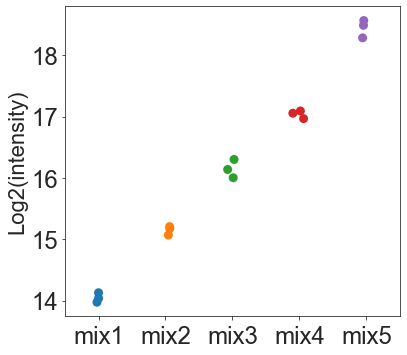

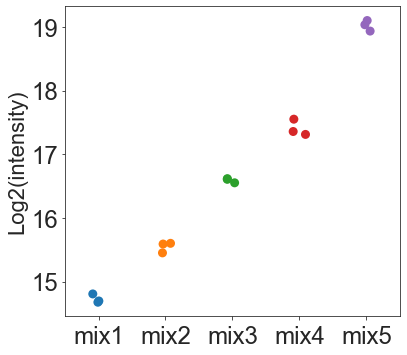

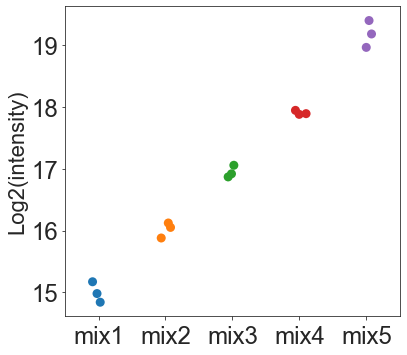

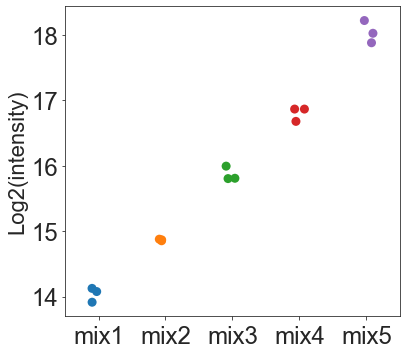

In [45]:
import seaborn as sns
plt.rcParams['font.family'] = 'Arial'

for names in ["1/sp|Q8NC51|PAIRB_HUMAN","1/sp|P46778|RL21_HUMAN","1/sp|P32119|PRDX2_HUMAN","1/sp|P06454|PTMA_HUMAN"]:
    plt.figure(figsize=(6, 5.7), edgecolor='#04253a')
    g=sns.stripplot(x="name", y=names, data=woca, jitter=True,size=9) 
    g.tick_params(axis='x', which='major',labelsize=24, pad=5)
    g.tick_params(axis='y', which='major',labelsize=24)
    plt.xlabel('')
    plt.ylabel('Log2(intensity)', fontsize=22)
    savename=names.split('|')[-1]
    plt.savefig(r'D:\\project7_SMAD\\figure2\\quantification\\%s.svg' % savename,dpi=800,bbox_inches='tight')
    plt.show()

In [19]:
dfdf_pro2=np.log2(dfdf_pro)
dfdf_pro2

,:/yuming/2023/20230312/quantification/mzxml/MIX_1_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_1_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_2_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_2_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_2_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_3_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_4_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_5_3.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_1.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_2.mzXML,:/yuming/2023/20230312/quantification/mzxml/MIX_6_3.mzXML
Unnamed: 0,,,,,,,,,,,,,,,,,,
1/sp|P38646|GRP75_HUMAN,20.844607,20.799535,20.648675,20.337637,20.411950,20.348600,19.836366,19.855808,19.767837,18.956412,19.017816,18.942110,17.920697,18.022279,17.735523,17.409148,17.337879,17.346037
1/sp|O43175|SERA_HUMAN,21.561654,21.486723,21.441715,21.142721,21.118201,21.191037,20.522263,20.377177,20.541592,19.750584,19.799708,19.753558,18.774753,18.829403,18.828005,18.035591,17.975783,18.021906
2/sp|P30613|KPYR_HUMAN/sp|P14618|KPYM_HUMAN,19.310897,19.196780,19.270457,19.181428,19.085993,18.011375,18.633005,18.556647,18.469234,17.718807,17.782538,17.739673,16.832705,16.803163,16.709636,15.879653,15.752507,15.715632
1/sp|P62258|1433E_HUMAN,21.161659,20.957282,21.026948,20.789282,20.826081,20.826205,20.191504,20.151883,20.120777,19.433119,19.409199,19.520992,18.687562,18.587671,18.559837,17.922040,17.779169,17.806249
2/sp|P52597|HNRPF_HUMAN/sp|P31943|HNRH1_HUMAN,16.841375,16.719795,16.620835,16.561755,16.754375,16.418101,16.501098,16.408739,16.592752,16.314804,15.950956,16.281620,15.491077,15.455807,14.531506,14.719436,14.783922,14.809429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4/sp|Q6ZMR3|LDH6A_HUMAN/sp|P07195|LDHB_HUMAN/sp|P07864|LDHC_HUMAN/sp|P00338|LDHA_HUMAN,19.274544,19.100051,19.110614,18.900010,18.874433,18.866775,18.391413,18.470030,18.467671,17.771228,17.629118,17.671751,16.814976,16.784167,16.935696,16.135567,16.108019,16.079966
1/sp|P62244|RS15A_HUMAN,20.692603,20.288896,20.312985,20.027704,20.014885,20.045726,19.458453,18.991096,19.369614,18.317565,18.348475,18.333631,17.724148,17.724435,17.516022,16.982750,17.010530,16.990554
2/sp|Q92841|DDX17_HUMAN/sp|P17844|DDX5_HUMAN,19.846365,19.927127,19.946819,19.786591,19.694494,19.780963,19.331930,18.472771,19.187362,18.605007,18.525713,18.524611,17.588488,17.510312,17.610379,16.783633,16.727284,16.788126


In [8]:
df_pro10.columns=[item.split('/')[-1].split('.')[0] for item in df_pro10.columns]

In [9]:
df_pro2.columns=[item.split('/')[-1].split('.')[0] for item in df_pro2.columns]

In [10]:
df_pro2

,MIX_1_1,MIX_1_2,MIX_1_3,MIX_3_1,MIX_3_2,MIX_3_3,MIX_4_1,MIX_4_2,MIX_4_3,MIX_5_1,MIX_5_2,MIX_5_3,MIX_6_1,MIX_6_2,MIX_6_3
Unnamed: 0,,,,,,,,,,,,,,,
LAAVDATVNQVLASR,18.676200,18.792421,18.697055,17.737379,17.796738,17.611932,17.034660,16.913435,16.873915,15.910630,15.857375,15.963481,14.911647,15.047334,14.921461
LVVEC(UniMod:4)VMNNVTC(UniMod:4)TR,17.484818,17.546324,17.409889,16.840259,16.717246,16.843916,16.186079,15.881865,16.077177,14.956801,14.881183,14.995230,14.177824,13.970852,14.111634
SQIHDIVLVGGSTR,16.268920,14.544314,14.737974,18.193635,16.764686,16.733180,17.318683,16.379362,16.434799,15.891580,16.395989,16.333996,15.608891,15.555289,15.516675
LATQLTGPVMPVR,19.781864,19.793393,17.682009,17.617334,17.615027,17.675318,17.640887,17.263994,17.939289,16.258516,16.161771,16.429008,15.297915,15.718037,15.733110
IDTIEIITDR,19.589989,19.402395,19.478694,18.529647,18.487915,18.662216,17.670242,17.696866,17.692052,16.878042,16.864799,16.898943,16.069377,15.930070,16.019581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
(UniMod:5)SLPLNPKPFLNGLTGKPVMVK,17.213514,17.258456,17.268257,16.418681,16.851818,16.254191,16.075738,15.732125,15.805233,14.759590,15.034739,15.063129,14.480901,14.289089,14.084567
AFVDFLSDEIKEER,17.567720,17.616955,17.626527,17.224332,17.361332,17.198391,16.347822,16.419124,16.177778,15.310490,15.366841,15.380833,14.492104,14.555418,14.524450
MFVGGLSWDTSK,17.329086,17.126274,17.294424,16.960100,16.659924,16.394067,16.052012,15.955620,15.830232,15.351891,15.378352,15.056042,14.511166,14.178326,14.010964


In [11]:
df_pro10

,MIX_1_1,MIX_1_2,MIX_1_3,MIX_3_1,MIX_3_2,MIX_3_3,MIX_4_1,MIX_4_2,MIX_4_3,MIX_5_1,MIX_5_2,MIX_5_3,MIX_6_1,MIX_6_2,MIX_6_3
Unnamed: 0,,,,,,,,,,,,,,,
LAAVDATVNQVLASR,5.622096,5.657082,5.628375,5.339483,5.357352,5.301720,5.127944,5.091451,5.079555,4.789577,4.773545,4.805487,4.488853,4.529699,4.491807
LVVEC(UniMod:4)VMNNVTC(UniMod:4)TR,5.263455,5.281970,5.240899,5.069423,5.032393,5.070524,4.872495,4.780918,4.839713,4.502446,4.479683,4.514014,4.267950,4.205645,4.248025
SQIHDIVLVGGSTR,4.897433,4.378275,4.436572,5.476830,5.046673,5.037189,5.213443,4.930679,4.947367,4.783842,4.935684,4.917023,4.698745,4.682609,4.670985
LATQLTGPVMPVR,5.954935,5.958405,5.322815,5.303346,5.302652,5.320801,5.310436,5.196980,5.400264,4.894301,4.865178,4.945624,4.605131,4.731601,4.736138
IDTIEIITDR,5.897174,5.840703,5.863671,5.577980,5.565417,5.617887,5.319273,5.327287,5.325838,5.080797,5.076810,5.087089,4.837365,4.795429,4.822374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
(UniMod:5)SLPLNPKPFLNGLTGKPVMVK,5.181784,5.195313,5.198263,4.942516,5.072903,4.892999,4.839279,4.735841,4.757849,4.443079,4.525908,4.534454,4.359186,4.301445,4.239877
AFVDFLSDEIKEER,5.288411,5.303232,5.306113,5.185040,5.226282,5.177232,4.921185,4.942649,4.869996,4.608917,4.625880,4.630092,4.362558,4.381617,4.372295
MFVGGLSWDTSK,5.216575,5.155522,5.206140,5.105499,5.015137,4.935106,4.832137,4.803120,4.765375,4.621380,4.629345,4.532320,4.368296,4.268101,4.217720


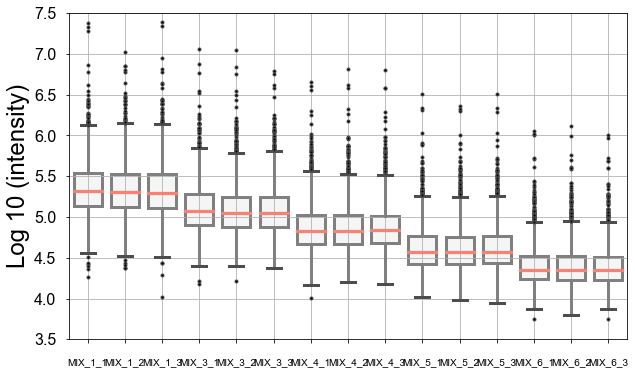

In [12]:
# Plot all common peptides after take log10 

matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_pro10, orient='v',color="grey", boxprops=dict(facecolor="whitesmoke",edgecolor='grey',linewidth=3), 
            whiskerprops=dict(color="grey",linewidth=3), medianprops=dict(color="salmon",linewidth=3.2), width=0.75,fliersize=6,
           flierprops=dict(markerfacecolor="black", marker="."),linewidth=3)
#plt.rc('xtick', labelsize=12, fontfamily='Arial')
#plt.rc('ytick', labelsize=12, fontfamily='Arial')
plt.ylabel('Log 10 (intensity)',fontsize=24)
plt.tick_params(axis='x', which='major', pad=15)
plt.tick_params(axis='y', which='major', pad=9)
plt.xticks(fontsize=10)
plt.yticks(fontsize=16)
plt.ylim(3.5,7.5)
plt.grid()
#plt.savefig('D:\\project7_SMAD\\quantification assessment\\all_common_pep.tiff', dpi=600)
plt.show()

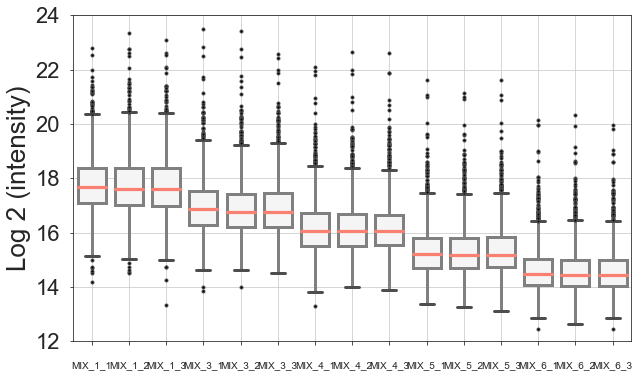

In [13]:
# Plot all common peptides after take log2

matplotlib.rcParams['font.family'] = "Arial"
plt.figure(figsize=(10, 6))
sns.set_style("ticks")
sns.boxplot(data=df_pro2, orient='v',color="grey", boxprops=dict(facecolor="whitesmoke",edgecolor='grey',linewidth=3), 
            whiskerprops=dict(color="grey",linewidth=3), medianprops=dict(color="salmon",linewidth=3.2), width=0.75,fliersize=6,
           flierprops=dict(markerfacecolor="black", marker="."),linewidth=3)
#plt.rc('xtick', labelsize=12, fontfamily='Arial')
#plt.rc('ytick', labelsize=12, fontfamily='Arial')
plt.ylabel('Log 2 (intensity)',fontsize=26)
plt.tick_params(axis='x', which='major', pad=16)
plt.tick_params(axis='y', which='major', pad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=22)
plt.ylim(12,24)
plt.grid()
plt.savefig('D:\\project7_SMAD\\quantification assessment\\all_common_pep_log2.tiff', dpi=600)
plt.show()

In [283]:
fileslist1 = []
dir = 'D:\\yuming\\2023\\20230312\\quantification'
for file in os.listdir(dir):
    if file.endswith(".raw"):
        fileslist1.append(os.path.join(dir, file))
print(fileslist1)

['D:\\yuming\\2023\\20230312\\quantification\\MIX_2_1.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_2_2.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_2_3.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_3_1.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_3_2.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_3_3.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_4_1.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_4_2.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_4_3.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_5_1.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_5_2.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_5_3.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_6_1.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_6_2.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_6_3.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_1_1.raw', 'D:\\yuming\\2023\\20230312\\quantification\\MIX_1_2.ra

In [370]:
def get_areadf(df=df_range16):
    area_cols = [x for x in df.columns if 'area' in x]
    df[area_cols]
    #area_df = df.iloc[:, 0:9].join(np.log2(df[area_cols[1:]]))
    area_df = np.log10(df[area_cols[1:]])
    area_df.index = df.mz
    area_df.dropna(inplace=True)
    columnames=[item.split(':')[1].split('_r')[0] for item in area_df.columns.tolist()]
    area_df.columns=columnames
    newdf=area_df.reindex(sorted(df_test.columns),axis=1)
    return(newdf)